In [1]:
import pandas as pd

In [2]:
import torch
from torch import nn, optim

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
import random

In [6]:
import numpy as np

In [7]:
import matplotlib.pyplot as plot

In [8]:
from string import punctuation

In [9]:
df = pd.read_csv("D:/git/dados/nlp/dialogs.txt", encoding="utf-8",
                 header=None, names=["pessoa_a", "pessoa_b"], sep="\t")
df

,pessoa_a,pessoa_b
0,"hi, how are you doing?",i'm fine. how about yourself?
1,i'm fine. how about yourself?,i'm pretty good. thanks for asking.
2,i'm pretty good. thanks for asking.,no problem. so how have you been?
3,no problem. so how have you been?,i've been great. what about you?
4,i've been great. what about you?,i've been good. i'm in school right now.
...,...,...
3720,that's a good question. maybe it's not old age.,are you right-handed?
3721,are you right-handed?,yes. all my life.
3722,yes. all my life.,you're wearing out your right hand. stop using...
3723,you're wearing out your right hand. stop using...,but i do all my writing with my right hand.


In [10]:
contraction_dict = {
    "aren't": "are not", "can't": "can not", "could've": "could have",
    "couldn't": "could not", "daren't": "dare not", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he's": "he is",
    "how'd": "how had", "how're": "how are", "how's": "how is",
    "how've": "how have", "i'd": "i had", "i'm": "i am",
    "i've": "i have", "isn't": "is not", "it's": "it is",
    "might've": "might have", "mightn't": "might not", "must've": "must have",
    "mustn't": "must not", "needn't": "need not", "oughtn't": "ought not",
    "shan't": "shall not", "she'd": "she had", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "that'd": "that had",
    "that's": "that is", "there'd": "there had", "there's": "there is",
    "they'd": "they had", "they're": "you are", "they've": "they have",
    "wasn't": "was not", "we'd": "we had", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what'd": "what had",
    "what're": "what are", "what's": "what is", "what've": "what have",
    "when'd": "when had", "when're": "when are", "when's": "when is",
    "when've": "when have", "where'd": "where had", "where're": "where are",
    "where's": "where is", "where've": "where have", "who'd": "who had",
    "who're": "who are", "who's": "who is", "who've": "who have",
    "why'd": "why had", "why're": "why are", "why's": "why is",
    "why've": "why have", "would've": "would have", "wouldn't": "would not",
    "you're": "you are", "you've": "you have", "'cause": "because", 
    "ain't": "is not", "aren't": "are not", "can't": "cannot", 
    "could've": "could have", "he's": "he is", "how'll": "how will",
    "i'll": "i will", "it'll": "it will", "it's": "it is", 
    "she'll": "she will", "she's": "she is", "that'll": "that will",
    "there'll": "there will", "they'll": "they will", "they're": "they are",
    "we'll": "we will", "we're": "we are", "what'll": "what will",
    "when'll": "when will", "where'll": "where will", "who'll": "who will",
    "you're": "you are", "you'll": "you will"
}

In [11]:
TABLE_LIMPAR = str.maketrans("", "", "\u200b" + "\u000b" + punctuation)
def limpar( texto ):
    texto_limpo = texto.lower()
    novo_texto = []
    for token in texto_limpo.split(" "):
        novo_token = contraction_dict.get(token, token)
        novo_texto.append(novo_token)
    return (" ".join(novo_texto)).translate(TABLE_LIMPAR)

In [12]:
print("Frase original: ", df["pessoa_a"][3720]) 
print("Frase limpa: ", limpar(df["pessoa_a"][3720]))

Frase original:  that's a good question. maybe it's not old age.
Frase limpa:  that is a good question maybe it is not old age


In [13]:
df["pessoa_a_limpa"] = df["pessoa_a"].apply( limpar )
df["pessoa_b_limpa"] = df["pessoa_b"].apply( limpar )
df

,pessoa_a,pessoa_b,pessoa_a_limpa,pessoa_b_limpa
0,"hi, how are you doing?",i'm fine. how about yourself?,hi how are you doing,i am fine how about yourself
1,i'm fine. how about yourself?,i'm pretty good. thanks for asking.,i am fine how about yourself,i am pretty good thanks for asking
2,i'm pretty good. thanks for asking.,no problem. so how have you been?,i am pretty good thanks for asking,no problem so how have you been
3,no problem. so how have you been?,i've been great. what about you?,no problem so how have you been,i have been great what about you
4,i've been great. what about you?,i've been good. i'm in school right now.,i have been great what about you,i have been good i am in school right now
...,...,...,...,...
3720,that's a good question. maybe it's not old age.,are you right-handed?,that is a good question maybe it is not old age,are you righthanded
3721,are you right-handed?,yes. all my life.,are you righthanded,yes all my life
3722,yes. all my life.,you're wearing out your right hand. stop using...,yes all my life,you are wearing out your right hand stop using...
3723,you're wearing out your right hand. stop using...,but i do all my writing with my right hand.,you are wearing out your right hand stop using...,but i do all my writing with my right hand


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [15]:
dicionario = { 
    "<UNKNOWN>": 0,
    "<PAD>": 1,
    "<BOS>": 2,
    "<EOS>": 3
}

In [16]:
BOS_INDEX = dicionario["<BOS>"]
EOS_INDEX = dicionario["<EOS>"]
PADDING_INDEX = dicionario["<PAD>"]
UNKNOWN_INDEX = dicionario["<UNKNOWN>"]

In [17]:
def vetorizador_texto( frase, dicionario, readwrite = True, eos = None, bos = None, unknown = 0 ):
    lista_tokens_numericos = []
    contador = len(dicionario)
    for idx, token in enumerate(frase.split(" ")):
        numero = dicionario.get(token, unknown)
        if readwrite and token not in dicionario:
            numero = contador
            dicionario[token] = numero
            contador += 1
        lista_tokens_numericos.append( numero )                
    if eos is not None:
        lista_tokens_numericos.append( eos )
    if bos is not None:
        lista_tokens_numericos.insert( bos, 0 )
        
    return lista_tokens_numericos

In [18]:
def vetorizador( textos, dicionario, readwrite = False, eos = None, bos = None, unknown = UNKNOWN_INDEX ):
    lista_frases_numeros = [ ]
    for frase in textos:
        texto_vetorizado = vetorizador_texto( frase, dicionario, readwrite, 
                                                                eos = eos, bos = bos, unknown = unknown)
        lista_frases_numeros.append( texto_vetorizado )
    return lista_frases_numeros

In [19]:
X_pessoa_A = vetorizador( df["pessoa_a_limpa"], dicionario, True, unknown = UNKNOWN_INDEX, 
                         bos = BOS_INDEX, eos = None
                         # bos = BOS_INDEX, eos = EOS_INDEX
                        )
X_pessoa_B = vetorizador( df["pessoa_b_limpa"], dicionario, True, unknown = UNKNOWN_INDEX, 
                         bos = None, eos = EOS_INDEX
                         # bos = BOS_INDEX, eos = EOS_INDEX
                        )


In [20]:
MAX_PALAVRAS_APRENDIDAS = len(dicionario)
MAX_PALAVRAS_APRENDIDAS

2498

In [21]:
print(X_pessoa_B[0])
print(X_pessoa_B[1])
print(X_pessoa_B[2])
print(X_pessoa_B[3])
print(X_pessoa_B[4])

[9, 10, 11, 5, 12, 13, 3]
[9, 10, 14, 15, 16, 17, 18, 3]
[19, 20, 21, 5, 22, 7, 23, 3]
[9, 22, 23, 24, 25, 12, 7, 3]
[9, 22, 23, 15, 9, 10, 26, 27, 28, 29, 3]


In [22]:
dicionario_reverso = {}
for chave in dicionario.keys():
    valor = dicionario[chave]
    dicionario_reverso[valor] = chave
len(dicionario_reverso)    

2498

In [23]:
numero = dicionario["school"]
print("Numero da palavra School: ", numero)
print(f"Palavra do numero {numero}: ", dicionario_reverso[numero])

Numero da palavra School:  27
Palavra do numero 27:  school


In [24]:
# encoder = LabelEncoder()
# oh_encoder = OneHotEncoder(sparse_output=False)

In [25]:
# Y_label = encoder.fit_transform(Y_draft)
# Y_label = Y_label.reshape(-1, 1)
# Y_label

In [26]:
# encoder.classes_

In [27]:
# Y_oh = oh_encoder.fit_transform(Y_label)
# oh_encoder.categories_

In [28]:
# Y_oh

In [29]:
# NUM_CLASSES = Y_oh.shape[1]
# NUM_CLASSES

In [30]:
# # Y = torch.tensor(df["type_number"], dtype=torch.float32)
# # Y = torch.reshape( Y, (-1, 1) )
# # Y.shape
# Y = torch.tensor(Y_oh, dtype=torch.float32)
# Y

In [31]:
# [0, 0, 1, 0, 0, 0, 1, 0, 1, 1] "Bom dia como vai voce" 
# [0, 1, 0, 0, 0, 1, 0, 1, 2, 0] "Ontem houve uma explosao de gas no bairro Jaguare em São Paulo"
# [0, 0, 0, 0, 0, 1, 0, 0, 1, 0] "Vou sair tchau"

In [32]:
# dicionario = {
#     "Bom": 1,
#     "dia": 2,
#     "como": 3,
#     "vai": 4,
#     "voce": 5,
#     "Ontem": 6,
#     "houve": 7,
# ....
# }

# [0, 0, 0, 0,  0,  0,  0,  1,  2,  3,  4,  5] "Bom dia como vai voce" 
# [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] "Ontem houve uma explosao de gas no bairro Jaguare em São Paulo"
# [0, 0, 0, 0,  0,  0,  0,  0,  0, 18, 20, 21] "Vou sair tchau"

In [33]:
MAIOR_FRASE = 0
for lista_numeros in X_pessoa_A:
    if len(lista_numeros) > MAIOR_FRASE:
        MAIOR_FRASE = len(lista_numeros)
for lista_numeros in X_pessoa_B:
    if len(lista_numeros) > MAIOR_FRASE:
        MAIOR_FRASE = len(lista_numeros)        
MAIOR_FRASE

21

In [34]:
def padding( lista_numeros, size, elemento_padding, left=True):
    numero_pads = size - len(lista_numeros)
    pads = []
    for _ in range(numero_pads):
        pads.append(elemento_padding)
    # pads = [1, 1, 1, 1, 1]
    nova_lista = []
    if left:
        nova_lista.extend(pads)
        nova_lista.extend(lista_numeros)
    else:
        nova_lista.extend(lista_numeros)
        nova_lista.extend(pads)
    return nova_lista

In [35]:
# valor_pad = dicionario["<PAD>"]
# padding(X_draft[7], 30, valor_pad, False)

In [36]:
X_pessoa_a_padded = []
for x in X_pessoa_A:
    X_pessoa_a_padded.append(padding(x, MAIOR_FRASE, PADDING_INDEX))
    # pads = [1, 1, 1, 1, 1, 34, 56, 12, 0, 43, 2]
X_pessoa_b_padded = []
for x in X_pessoa_B:
    X_pessoa_b_padded.append(padding(x, MAIOR_FRASE, PADDING_INDEX, left=False))    

In [37]:
print(X_pessoa_a_padded[0:5])
print(X_pessoa_b_padded[0:5])

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 5, 0, 6, 7, 8], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 10, 0, 11, 5, 12, 13], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 10, 0, 14, 15, 16, 17, 18], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 19, 20, 0, 21, 5, 22, 7, 23], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 22, 0, 23, 24, 25, 12, 7]]
[[9, 10, 11, 5, 12, 13, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [9, 10, 14, 15, 16, 17, 18, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [19, 20, 21, 5, 22, 7, 23, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [9, 22, 23, 24, 25, 12, 7, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [9, 22, 23, 15, 9, 10, 26, 27, 28, 29, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


In [38]:
input_tensor = torch.tensor( X_pessoa_a_padded, dtype=torch.long ).to( device )
target_tensor = torch.tensor( X_pessoa_b_padded, dtype=torch.long ).to( device )
print("input_tensor shape: ", input_tensor.shape)
print("target_tensor shape: ", target_tensor.shape)

input_tensor shape:  torch.Size([3725, 21])
target_tensor shape:  torch.Size([3725, 21])


In [39]:
print(f"Y  dim({target_tensor.ndim})\tshape={target_tensor.shape}\ttype=({target_tensor.dtype})")
print(f"X  dim({input_tensor.ndim})\tshape={input_tensor.shape}\ttype=({input_tensor.dtype})")

Y  dim(2)	shape=torch.Size([3725, 21])	type=(torch.int64)
X  dim(2)	shape=torch.Size([3725, 21])	type=(torch.int64)


In [40]:
class Encoder( nn.Module ):
    def __init__(self, embeddings_in, embedding_out, padding_idx, hidden_size):
        super(Encoder, self).__init__()

        self.embedding = nn.Embedding(num_embeddings = embeddings_in, 
                                      embedding_dim = embedding_out, 
                                      padding_idx = padding_idx)
        self.lstm = nn.LSTM(
            input_size = embedding_out,
            hidden_size = hidden_size,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding( x )
        lstm_out, (lstm_hidden, lstm_cell) = self.lstm( embedded )
        return lstm_hidden, lstm_cell
        

In [41]:
class Decoder( nn.Module ):
    def __init__(self, embeddings_in, embedding_out, padding_idx, hidden_size):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(num_embeddings = embeddings_in, 
                                      embedding_dim = embedding_out, 
                                      padding_idx = padding_idx)
        self.lstm = nn.LSTM(
            input_size = embedding_out,
            hidden_size = hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear( hidden_size, embeddings_in )

    def forward(self, x, hidden, cell):
        # print("Shape de entrada do Decoder: ", x.shape)
        # Verificar shape do X 
        x = x.reshape(-1, 1)
        embedded = self.embedding( x )
        output, (hidden, cell) = self.lstm( embedded, (hidden, cell) )
        squeezed_output = output.squeeze( 1 )
        logits = self.fc( squeezed_output )
        return logits, hidden, cell

In [42]:
class Seq2Seq( nn.Module ):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab_size = vocab_size

    def forward(self, input_tensor, target_tensor):
        batch_size = input_tensor.shape[0]
        target_len = target_tensor.shape[1]
        
        outputs = torch.zeros( batch_size, target_len, self.vocab_size, device=device )
        hidden, cell = self.encoder( input_tensor )

        input_token = torch.full( (batch_size, ), BOS_INDEX, dtype=torch.long, device=device )
        
        for idx_palavra in range(target_len):
            logits, hidden, cell = decoder( input_token, hidden, cell )
            outputs[ :, idx_palavra, :] = logits
            palavra_prevista = logits.argmax(1)
            input_token = palavra_prevista
        return outputs
        

In [43]:
DIMENSOES = 50
HIDDEN_SIZE = 60
EPOCAS = 3000

In [44]:
encoder = Encoder(embeddings_in = MAX_PALAVRAS_APRENDIDAS,
                          embedding_out = DIMENSOES,
                          padding_idx = PADDING_INDEX,
                          hidden_size = HIDDEN_SIZE)
decoder = Decoder(embeddings_in = MAX_PALAVRAS_APRENDIDAS,
                          embedding_out = DIMENSOES,
                          padding_idx = PADDING_INDEX,
                          hidden_size = HIDDEN_SIZE)
modelo = Seq2Seq( encoder, decoder, MAX_PALAVRAS_APRENDIDAS ).to( device )
otimizador = optim.Adam( modelo.parameters(), lr=0.01)
criterio = nn.CrossEntropyLoss(ignore_index=PADDING_INDEX) # Cross Entropy Perda

In [45]:
lista_loss = []
for epoca in range(EPOCAS):
    modelo.train()
    otimizador.zero_grad()
    outputs = modelo( input_tensor, target_tensor )
    outputs = outputs.reshape( -1, MAX_PALAVRAS_APRENDIDAS )
    target_flat = target_tensor.reshape( -1 )
    loss = criterio( outputs, target_flat )
    lista_loss.append( loss )
    loss.backward()
    otimizador.step()
    if epoca % 100 == 0:
        print(f"Epoca: {epoca}\tLoss: {loss}")    

Epoca: 0	Loss: 7.818625450134277
Epoca: 100	Loss: 4.675904273986816
Epoca: 200	Loss: 3.933338165283203
Epoca: 300	Loss: 3.2145397663116455
Epoca: 400	Loss: 2.660451889038086
Epoca: 500	Loss: 2.2620086669921875
Epoca: 600	Loss: 1.969314694404602
Epoca: 700	Loss: 1.694705605506897
Epoca: 800	Loss: 1.4738245010375977
Epoca: 900	Loss: 1.3304364681243896
Epoca: 1000	Loss: 1.2032842636108398
Epoca: 1100	Loss: 1.0228679180145264
Epoca: 1200	Loss: 0.9409636855125427
Epoca: 1300	Loss: 0.8328025341033936
Epoca: 1400	Loss: 0.8119645118713379
Epoca: 1500	Loss: 0.6592235565185547
Epoca: 1600	Loss: 0.6148064732551575
Epoca: 1700	Loss: 0.5668890476226807
Epoca: 1800	Loss: 0.4959689974784851
Epoca: 1900	Loss: 0.41512563824653625
Epoca: 2000	Loss: 0.42307451367378235
Epoca: 2100	Loss: 0.397673636674881
Epoca: 2200	Loss: 0.34387147426605225
Epoca: 2300	Loss: 0.32814013957977295
Epoca: 2400	Loss: 0.3018355369567871
Epoca: 2500	Loss: 0.897081196308136
Epoca: 2600	Loss: 0.3393179476261139
Epoca: 2700	Loss:

C:\Users\anton\AppData\Local\Temp\ipykernel_9096\479406149.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  lista_tensor = torch.tensor( lista_loss )


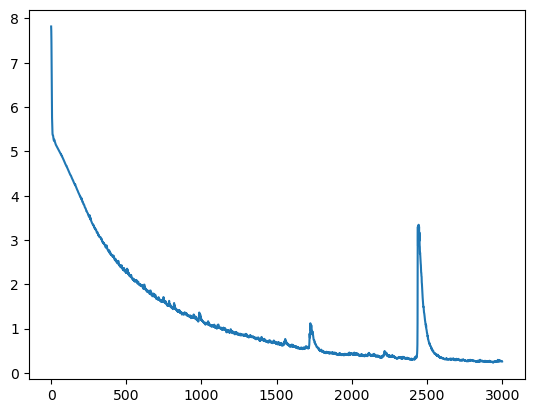

In [46]:
lista_tensor = torch.tensor( lista_loss ) 
plot.plot( lista_tensor )

In [47]:
def responder( frase, max_len = 10 ):
    frase_limpa = limpar( frase )
    print( "Respondendo frase limpa: ", frase_limpa)
    modelo.eval()
    entrada = vetorizador_texto( frase_limpa, dicionario, False, eos = EOS_INDEX, unknown = UNKNOWN_INDEX)
    print("Entrada:", entrada)
    entrada_padded = padding(entrada, max_len, PADDING_INDEX)
    # print( "Entrada Padded: ", entrada_padded)
    input_tensor_entrada = torch.tensor([entrada_padded], dtype=torch.long).to( device )

    with torch.no_grad():
        hidden, cell = modelo.encoder( input_tensor_entrada )
        input_token  = torch.tensor([BOS_INDEX], dtype=torch.long).to( device )
        resposta = []
        for _ in range( max_len ):
            logits, hidden, cell = modelo.decoder(input_token, hidden, cell)
            palavra_idx = logits.argmax(1).item()
            # print("Palavra Idx: ", palavra_idx)
            if palavra_idx == EOS_INDEX:
                break
            if palavra_idx not in [BOS_INDEX, EOS_INDEX, PADDING_INDEX]:
                resposta.append( palavra_idx )
            input_token  = torch.tensor([palavra_idx], dtype=torch.long).to( device )
            # print("Resposta: ", resposta)
        respostas_em_palavras = []
        for resposta_idx in resposta:
            respostas_em_palavras.append(dicionario_reverso.get(resposta_idx, "<DESCONHECIDA>"))
        return " ".join(respostas_em_palavras)
    

In [48]:
responder("Hi how are you doing", 10)

Respondendo frase limpa:  hi how are you doing
Entrada: [4, 5, 6, 7, 8, 3]


'i will been been listen for a'

In [49]:
responder("thank you", 10)

Respondendo frase limpa:  thank you
Entrada: [64, 7, 3]


'well should just the too too'

In [50]:
responder("do you wanna talk about something else ?", 10)

Respondendo frase limpa:  do you wanna talk about something else 
Entrada: [30, 7, 0, 600, 12, 248, 751, 99, 3]


'i want to be loads shoppers'

In [51]:
responder("good luck with school", 10)

Respondendo frase limpa:  good luck with school
Entrada: [15, 43, 44, 27, 3]


'why you think nose'